# <center> Modern BERT
### <center> Fine-tune modern-BERT for **multi-label** sequence classification

## Environment Set Up

In [1]:
# Install Pytorch & scikit-learn libraries
!pip install "torch==2.5.0" "torchvision==0.20.0" -q
!pip install "setuptools<71.0.0" scikit-learn -q

# Install Hugging Face libraries
!pip install  --upgrade \
  "datasets==3.1.0" \
  "accelerate==1.2.1" \
  "hf-transfer==0.1.8" -q

# Install ModernBERT from github
!pip install "git+https://github.com/huggingface/transformers.git@6e0515e99c39444caae39472ee1b2fd76ece32f1" --upgrade -q

# Install other libraries
!pip install seaborn -q


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Built-in imports
import os
import json

# Other modules are imported as we go...

In [3]:
# Set paths and other notebook parameters
dataset_path = "data/research_papers.csv"
model_id = "answerdotai/ModernBERT-base" # If you want a lighter/faster alternative: distilbert/distilbert-base-uncased

eval_path = "./evaluation"
model_path = "./model"

seed = 42

# Create dirs for later use
os.makedirs(eval_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

## Data Preprocessing

In [4]:
import pandas as pd

df = pd.read_csv(dataset_path)#.iloc[:5000]
display(df.head(3))

,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0


In [5]:
# Custom preprocessing pipeline #

df["text"] = df["TITLE"] + df["ABSTRACT"]

col_map = {
    "Computer Science": "computer_sci",
    #"Physics": "physics",
    "Mathematics": "maths",
    "Statistics": "stats",
    #"Quantitative Biology": "quant_biology",
    #"Quantitative Finance": "quant_finance"
}

label_cols = list(col_map.values())

# Standardize label names to more readable forms
df.rename(columns=col_map, inplace=True)

# Keep only the columns required for training
df = df[["text"] + label_cols]

## Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# Perform train/test split
train_df, test_df = train_test_split(df, test_size=0.1, shuffle=True, random_state=seed)
train_df, eval_df = train_test_split(train_df, test_size=0.1, shuffle=True, random_state=seed)

# Convert to HuggingFace Dataset objects
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df.reset_index(drop=True))

# Create a DatasetDict
split_dataset = DatasetDict({
    "train": train_dataset,
    "eval": eval_dataset
})

# Save datasets to use later in model testing
train_df.to_csv("data/train_set.csv", index=False)
eval_df.to_csv("data/eval_set.csv", index=False)
test_df.to_csv("data/test_set.csv", index=False)

# Report datasets size
print(f"train-set: {train_df.shape}")
print(f"eval-set: {eval_df.shape}")
print(f"test-set: {test_df.shape}")

train-set: (16986, 4)
eval-set: (1888, 4)
test-set: (2098, 4)


## Tokenize Data

In [7]:
from transformers import AutoTokenizer

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Tokenize helper function
def tokenize(batch):
    toks = tokenizer(batch["text"], padding="max_length", truncation=True)

    # multi-hot labels as list
    toks["labels"] = [
        [int(batch[col][i]) for col in label_cols]
        for i in range(len(batch["text"]))
    ]
    toks["labels"] = [list(map(float, lbl)) for lbl in toks["labels"]]
    return toks

# Tokenize dataset
tokenized_dataset = split_dataset.map(tokenize, batched=True, remove_columns=["text"]+label_cols)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16986 [00:00<?, ? examples/s]

Map:   0%|          | 0/1888 [00:00<?, ? examples/s]

## Load Model

In [8]:
from transformers import AutoModelForSequenceClassification

# Load model configured for multi-label classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=len(label_cols),
    problem_type="multi_label_classification"
)

# WARNING: You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Evaluation Metrics

In [9]:
import numpy as np
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        #"precision": precision_score(labels, preds, average="macro", zero_division=0),
        #"recall": recall_score(labels, preds, average="macro", zero_division=0),
        #"f1": f1_score(labels, preds, average="macro", zero_division=0),
    }

## Training Loop

In [10]:
import torch
import gc

# Set training device
if torch.cuda.is_available():
    torch.cuda.empty_cache(); gc.collect()
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Training device: {device}")
# NOTE. this notebook uses the HF Trainer with PyTorch, and will automatically use available CUDA GPUs if torch.cuda.is_available()

Training device: cuda


In [11]:
from huggingface_hub import HfFolder
from transformers import Trainer, TrainingArguments

# Define training args
training_args = TrainingArguments(
    output_dir=model_path,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    num_train_epochs=1,
    optim="adamw_torch_fused",
    logging_strategy="steps",
    logging_steps=100,
    eval_strategy="steps",
    save_strategy="steps",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=torch.cuda.is_available()
)

Remember:
- **Train size**: Number of samples/examples in your training dataset.
- **Batch size**: Number of samples processed before the model’s parameters are updated.
- **Epoch**: one full pass through the entire training dataset.
- **Step**: one update of the model's parameters (i.e., one batch processed).

$$ \text{steps per epoch} = \frac{\text{train size}}{\text{batch size}}$$
$$ \text{total training steps} = \text{steps per epoch} \times \text{number of epochs}$$

In [12]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"].shuffle(seed=seed), # Shuffle training set
    eval_dataset=tokenized_dataset["eval"],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    data_collator=data_collator
)

trainer.train(); # Inspect real time GPU memory consumption with this command: `watch -n 2 nvidia-smi`

Step,Training Loss,Validation Loss,Accuracy
100,1.063400,0.432286,0.605932
200,0.797800,0.347025,0.695975
300,0.671800,0.315552,0.702331
400,0.624100,0.303056,0.707627
500,0.586400,0.301792,0.692797
600,0.609200,0.288661,0.705508
700,0.607300,0.284851,0.706568
800,0.577600,0.282173,0.710275
900,0.592100,0.281820,0.710805
1000,0.562800,0.280469,0.711864


**Accuracy**
$$
\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{I}\left(\hat{Y}_i = Y_i\right)
$$

> Where:
> - $\hat{Y}_i$: predicted label set (binary vector) for sample $i$
> - $Y_i$: true label set
> - $\mathbf{I}$: indicator function (1 if all predicted labels match, else 0)
> - $N$: number of samples

The following metrics are computed using **micro averaging**:

**Precision**
$$
\text{Precision}_{\text{micro}} = \frac{\sum \text{TP}}{\sum \text{TP} + \sum \text{FP}}
$$

**Recall**
$$
\text{Recall}_{\text{micro}} = \frac{\sum \text{TP}}{\sum \text{TP} + \sum \text{FN}}
$$

**F1-score**
$$
\text{F1}_{\text{micro}} = 2 \cdot \frac{\text{Precision}_{\text{micro}} \cdot \text{Recall}_{\text{micro}}}{\text{Precision}_{\text{micro}} + \text{Recall}_{\text{micro}}}
$$

> Other Averaging Options: You can also compute **macro**, **samples**, or **weighted** versions by adjusting the way per-label or per-sample scores are averaged.

## Loss Analysis

In [13]:
# Log history
log_history = trainer.state.log_history

with open(eval_path+"/log_history.json", "w") as f:
    json.dump(log_history, f, indent=2)

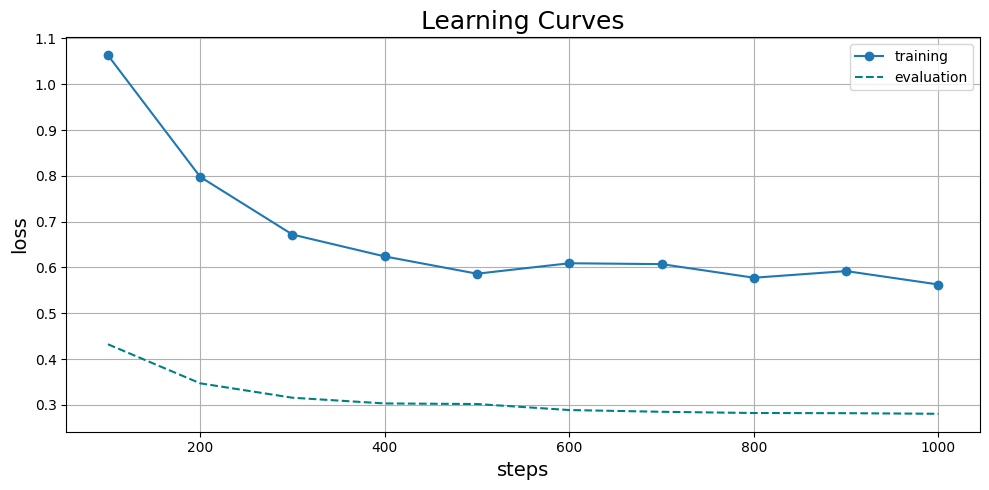

In [14]:
import matplotlib.pyplot as plt

# Get training steps and losses
train_loss_steps = [log["step"] for log in log_history if "loss" in log]
train_loss_values = [log["loss"] for log in log_history if "loss" in log]
eval_loss_steps = [log["step"] for log in log_history if "eval_loss" in log]
eval_loss_values = [log["eval_loss"] for log in log_history if "eval_loss" in log]

# Plot training vs eval loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_steps, train_loss_values, label="training", color='#1f77b4', marker='o')
plt.plot(eval_loss_steps, eval_loss_values, label="evaluation", color='#008080', linestyle='--')

plt.title("Learning Curves", fontsize=18)
plt.xlabel("steps", fontsize=14)
plt.ylabel("loss", fontsize=14)

plt.tight_layout()
plt.grid(True)
plt.legend()

plt.savefig(eval_path+"/learning_curves.png", dpi=300)
plt.show()

## Evaluation Analysis

In [15]:
# Run predictions on the evaluation set
preds = trainer.predict(tokenized_dataset["eval"])
probs = torch.sigmoid(torch.tensor(preds.predictions)).numpy()
y_pred = (probs >= 0.5).astype(int)

In [16]:
from sklearn.metrics import classification_report

# Classification report
report = classification_report(preds.label_ids, y_pred, target_names=label_cols, zero_division=0)

with open(eval_path+"/classification_report.txt", "w") as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

computer_sci       0.80      0.87      0.84       764
       maths       0.90      0.72      0.80       517
       stats       0.80      0.75      0.78       481

   micro avg       0.83      0.79      0.81      1762
   macro avg       0.84      0.78      0.80      1762
weighted avg       0.83      0.79      0.81      1762
 samples avg       0.61      0.59      0.58      1762



---